# 📌 파이썬으로 데이터 둘러보기

In [1]:
import pandas as pd
data = pd.read_csv('titanic.csv')
data

,Pclass,Name,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,C,1,1912-03-29
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,NaN,1,0,113803,S,1,1912-03-28
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,S,0,1912-04-03
...,...,...,...,...,...,...,...,...,...,...
880,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,S,0,1912-01-29
881,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,S,1,1912-03-30
882,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,S,0,1912-04-07
883,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,C,1,1912-03-01


In [2]:
data. head

<bound method NDFrame.head of      Pclass                                               Name   Gendr   Age  \
0         3                            Braund, Mr. Owen Harris    male  22.0   
1         1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
2         3                             Heikkinen, Miss. Laina  female  26.0   
3         1       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female   NaN   
4         3                           Allen, Mr. William Henry    male  35.0   
..      ...                                                ...     ...   ...   
880       2                              Montvila, Rev. Juozas    male  27.0   
881       1                       Graham, Miss. Margaret Edith  female  19.0   
882       3           Johnston, Miss. Catherine Helen "Carrie"  female  28.0   
883       1                              Behr, Mr. Karl Howell    male  26.0   
884       3                                Dooley, Mr. Patrick    male  32.0   

     SibS

# 📌 불필요한 컬럼 삭제 (Dropping columns), 누락된 결측치 처리 (Missing values)

In [3]:
data.columns

Index(['Pclass', 'Name', 'Gendr', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Embarked', 'Survived', 'ticket_date'],
      dtype='object')

In [4]:
dt_data = data.drop(columns=['Name', 'Ticket', 'ticket_date'])


In [5]:
dt_data.columns



Index(['Pclass', 'Gendr', 'Age', 'SibSp', 'Parch', 'Embarked', 'Survived'], dtype='object')

In [6]:
data.tail(1)


,Pclass,Name,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
884,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,Q,0,1912-03-05


In [7]:
# 결측치 출력
data[data['Embarked'].isnull()]


,Pclass,Name,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
15,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,NaN,1,1912-03-05
322,3,"Sage, Mr. George John Jr",male,28.0,8,2,CA. 2343,NaN,0,1912-03-26


In [8]:
# 결측치 개수만
data['Embarked'].isnull().sum()


np.int64(2)

# 📌 이상치 탐지 및 처리 (Outliers)

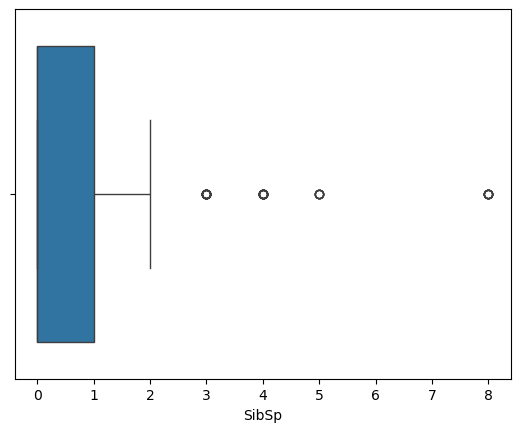

In [9]:
# 'SibSp' 컬럼 boxplot 그리기
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=data['SibSp'])
plt.show()


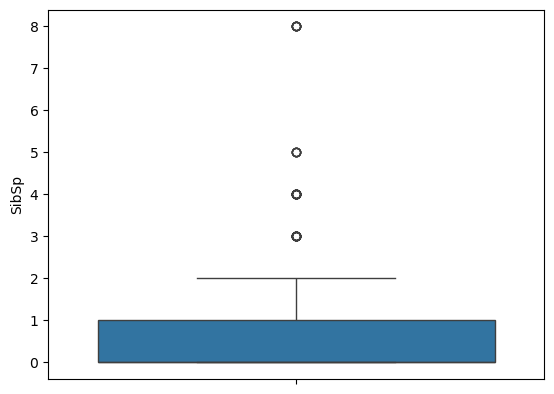

In [10]:
# 세로
sns.boxplot(y=data['SibSp'])
plt.show()


In [11]:
# 데이터의 'Age' 컬럼에 있는 모든 값에 대해, 70세 초과인 경우 그 값을 70으로 변경하고 그렇지 않은 경우 원래의 값을 유지하는 코드를 적어주세요

data['Age'] = data['Age'].apply(lambda x: 70 if x > 70 else x)

data.sort_values(by='Age', ascending=False)


,Pclass,Name,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
490,1,"Artagaveytia, Mr. Ramon",male,70.0,0,0,PC 17609,C,0,1912-01-12
743,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,S,0,1912-03-07
845,3,"Svensson, Mr. Johan",male,70.0,0,0,347060,S,0,1912-02-20
115,3,"Connors, Mr. Patrick",male,70.0,0,0,370369,Q,0,1912-02-03
279,3,"Duane, Mr. Frank",male,70.0,0,0,336439,Q,0,1912-02-20
...,...,...,...,...,...,...,...,...,...,...
106,3,"Moss, Mr. Albert Johan",male,NaN,0,0,312991,S,1,1912-01-27
156,3,"Corn, Mr. Harry",male,NaN,0,0,SOTON/OQ 392090,S,0,1912-04-01
185,3,"O'Brien, Mrs. Thomas (Johanna ""Hannah"" Godfrey)",female,NaN,1,0,370365,Q,1,1912-03-25
213,3,"Kiernan, Mr. Philip",male,NaN,1,0,367229,Q,0,1912-02-12


### 주관식 퀴즈

Q. 챗GPT(3.5)를 활용해서, matplotlib과 seaborn, distplot, scatterplot,boxplot의 차이점에 대해 조사하고 답변을 작성해 보세요.

A. 📌 Matplotlib

파이썬에서 가장 기본적인 시각화 라이브러리.

낮은 수준(low-level) API로 매우 자세한 커스터마이징이 가능함.

다양한 그래프(라인, 바, 히스토그램, 산점도 등)를 만들 수 있지만, 설정 코드가 길어질 수 있음.

📌 Seaborn

Matplotlib 기반의 고수준(high-level) 시각화 라이브러리.

통계적 그래프에 특화되어 있고, 코드가 더 간단하고 예쁘다 (기본 테마, 색상 자동 적용).

pandas DataFrame과 잘 연동됨.



# 📌 중복 데이터 처리 및 데이터 형태 변환처리(Removing duplicate data, apply, map, replace, rename)

## 주관식 퀴즈

Q. 챗GPT(3.5)를 활용해서, replace, map, apply 각 메서드별 차이점과 예시를 작성해 주세요

1. replace 메서드
🔹 특징

특정 값을 다른 값으로 치환할 때 사용한다.

Series와 DataFrame 모두 사용 가능하다.

조건식보다는 값 대 값 교체에 적합하다.

In [28]:
# replace 메서드 예시
# 성별 컬럼에서 'male' → 0, 'female' → 1로 변경
data.rename(columns={'Gendr': 'Gender'}, inplace=True)
data['Gender'] = data['Gender'].map({'male': 0, 'female': 1})

data. head

<bound method NDFrame.head of      Pclass                                               Name  Gender   Age  \
0         3                            Braund, Mr. Owen Harris     NaN  22.0   
1         1  Cumings, Mrs. John Bradley (Florence Briggs Th...     NaN  38.0   
2         3                             Heikkinen, Miss. Laina     NaN  26.0   
3         1       Futrelle, Mrs. Jacques Heath (Lily May Peel)     NaN   NaN   
4         3                           Allen, Mr. William Henry     NaN  35.0   
..      ...                                                ...     ...   ...   
880       2                              Montvila, Rev. Juozas     NaN  27.0   
881       1                       Graham, Miss. Margaret Edith     NaN  19.0   
882       3           Johnston, Miss. Catherine Helen "Carrie"     NaN  28.0   
883       1                              Behr, Mr. Karl Howell     NaN  26.0   
884       3                                Dooley, Mr. Patrick     NaN  32.0   

     SibS

2. map 메서드
🔹 특징

Series(컬럼)에서만 사용 가능하다.

딕셔너리나 함수(lambda)를 이용해 값을 변환한다.

매핑되지 않은 값은 NaN으로 처리될 수 있다.

In [ ]:
# map 메서드 예시
# 생존 여부를 문자로 변환
data['Survived'] = data['Survived'].map({0: 'No', 1: 'Yes'})


3. apply 메서드
🔹 특징

가장 범용적인 메서드

Series와 DataFrame 모두 사용 가능

복잡한 조건식이나 함수 적용에 적합하다.

처리 속도는 상대적으로 느릴 수 있다.

In [ ]:
# apply 메서드 예시
# 나이가 70 초과면 70으로 변경
data['Age'] = data['Age'].apply(lambda x: 70 if x > 70 else x)


In [ ]:
# . 1) 'Gendr' 컬럼의 이름을 'Gender'로 바꾸고, 2) 'male'을 '0', 'female'을 '1'로 바꾸는 코드를 적어 보세요.

# 1) 컬럼명 변경
data = data.rename(columns={'Gendr': 'Gender'})

# 2) 값 변경
data['Gender'] = data['Gender'].replace({'male': 0, 'female': 1})

data[['Gender']].head()


,Gender
0,0
1,1
2,1
3,1
4,0


# 📌 텍스트 처리 (Text handling)

## apply 함수란?

apply() 함수는 DataFrame의 각 행이나 열에 함수를 적용할 때 사용됩니다. 이 함수는 데이터 변환, 데이터 정리 또는 데이터 요약 작업에 유용하게 사용될 수 있습니다.
## lambda 함수란?

lambda 함수는 이름 없이 작성되는 익명 함수로, 간단한 한 줄 짜리 함수를 작성할 때 사용됩니다. apply()와 함께 사용하면 간결하고 동적인 데이터 처리가 가능합니다.

### 잠깐! 퀴즈
Q. txt = STON/OE. 3101282에서 숫자만 출력되도록 코드를 작성

In [ ]:
# filter와 isdigit을 사용하여 문자열에서 숫자만 추출하였다.
txt = "STON/OE. 3101282"
result = ''.join(filter(str.isdigit, txt))
print(result)


3101282


Q. 'Ticket' 컬럼에서 숫자(int)만 출력되도록 코드를 작성해 보세요.

In [ ]:
data['new_ticket'] = data['Ticket'].str.split().apply(lambda x: x[-1])
data['new_ticket'] = data['new_ticket'].replace({'LINE': '999999'})
data['new_ticket'] = data['new_ticket'].astype('int')
# 출력문 보이게
data[['Ticket', 'new_ticket']].head()

,Ticket,new_ticket
0,A/5 21171,21171
1,PC 17599,17599
2,STON/O2. 3101282,3101282
3,113803,113803
4,373450,373450


# 📌 날짜 및 시간 데이터 처리 (Datetime)

Q. 2022년 11월 24일부터 2023년 3월 15일까지의 일수를 datetime 라이브러리를 활용하여 계산해 주세요.

In [1]:
from datetime import datetime

start_date = datetime(2022, 11, 24)
end_date = datetime(2023, 3, 15)

days = (end_date - start_date).days
days


111

Q. 타이타닉이 침몰한 날짜는 1912년 4월 15일입니다. 침몰한 날짜를 기준으로 각 승객이 몇 일 전에 티켓을 구매했는지 볼 수 있도록 코드를 작성해 주세요.

In [8]:
import pandas as pd
from datetime import datetime

# 데이터 불러오기
data = pd.read_csv('titanic.csv')

# 침몰 날짜
sink_date = datetime(1912, 4, 15)

# 날짜 변환
data['ticket_date'] = pd.to_datetime(data['ticket_date'])

# 며칠 전 구매했는지 계산
data['days_before_sink'] = (sink_date - data['ticket_date']).dt.days

data. head()

,Pclass,Name,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date,days_before_sink
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,S,0,1912-01-12,94
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,C,1,1912-03-29,17
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23,52
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,NaN,1,0,113803,S,1,1912-03-28,18
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,S,0,1912-04-03,12


타이타닉 침몰일을 기준으로 한 티켓 구매 시점(days_before_sink)의 분포를 살펴본 결과,
대부분의 승객은 침몰일로부터 한 달 이내에 티켓을 구매했으며,
티켓 구매 시점 자체는 생존 여부와 뚜렷한 차이를 보이지 않았다.